# Movie Recommender System - Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to understand the MovieLens 1M dataset before building the recommendation model.

### Tasks

- Load the datasets
- Explore the structure of the data
- Check data quality
- Analyze users and movies
- Understand rating distribution
- Identify popular and highly-rated movies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

## Load Dataset

Load the MovieLens datasets into pandas DataFrames.

In [2]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")
users = pd.read_csv("../data/users.csv")

## Preview the Data

Display the first few rows of each dataset to understand its structure.

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
users.head()

,userId,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


## Dataset Shape

Check the number of rows and columns in each dataset.

In [6]:
# Basic Information
print(f"Movies Shape : {movies.shape}")
print(f"Ratings Shape : {ratings.shape}")
print(f"Users Shape : {users.shape}")

Movies Shape : (3883, 3)
Ratings Shape : (1000209, 4)
Users Shape : (6040, 5)


## Dataset Information

Inspect the data types, non-null values, and memory usage.

In [7]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  3883 non-null   int64
 1   title    3883 non-null   str  
 2   genres   3883 non-null   str  
dtypes: int64(1), str(2)
memory usage: 91.1 KB


In [8]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   userId     1000209 non-null  int64
 1   movieId    1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [9]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   userId      6040 non-null   int64
 1   gender      6040 non-null   str  
 2   age         6040 non-null   int64
 3   occupation  6040 non-null   int64
 4   zip         6040 non-null   str  
dtypes: int64(3), str(2)
memory usage: 236.1 KB


## Check Duplicate Records

Verify that there are no duplicate rows in any dataset.

In [10]:
print(f"Duplicate Movies : {movies.duplicated().sum()}")
print(f"Duplicate Ratings : {ratings.duplicated().sum()}")
print(f"Duplicate Userss : {users.duplicated().sum()}")

Duplicate Movies : 0
Duplicate Ratings : 0
Duplicate Userss : 0


## Summary Statistics

Generate descriptive statistics for the ratings dataset.

In [11]:
ratings.describe()

,userId,movieId,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


## Number of Unique Users

Find the total number of unique users in the ratings dataset.

In [12]:
ratings["userId"].nunique()

6040

## Number of Unique Movies

Find the total number of movies that have received at least one rating.

In [13]:
ratings["movieId"].nunique()

3706

## Rating Distribution

Count how many times each rating value appears.

In [14]:
ratings["rating"].value_counts().sort_index()

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

## Visualize Rating Distribution

Plot the frequency of each rating value.

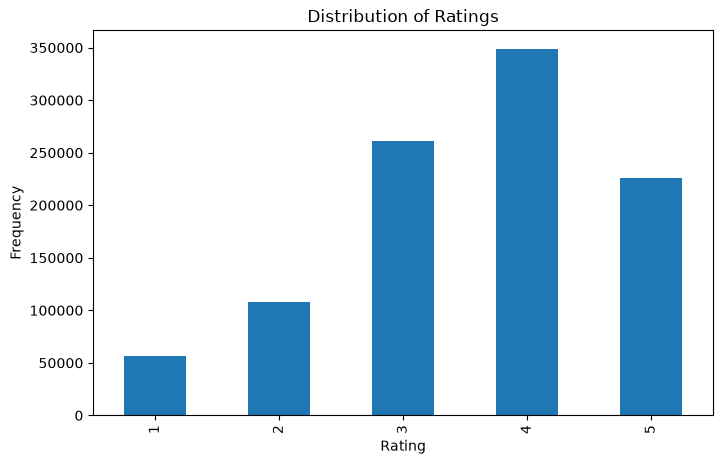

In [15]:
ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

## Most Active Users

Identify the users who have rated the highest number of movies.

In [16]:
user_activity = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
)

user_activity.head(10)

userId
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
dtype: int64

## Most Popular Movies

Find the movies with the highest number of ratings.

In [17]:
movie_popularity = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
)

movie_popularity.head(10)

movieId
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578
dtype: int64

In [18]:
# Merge

popular_movies = movie_popularity.reset_index(name="rating_count")

popular_movies = popular_movies.merge(
    movies,
    on="movieId"
)

popular_movies.head(10)

,movieId,rating_count,title,genres
0,2858,3428,American Beauty (1999),Comedy|Drama
1,260,2991,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi
2,1196,2990,Star Wars: Episode V - The Empire Strikes Back (1980),Action|Adventure|Drama|Sci-Fi|War
3,1210,2883,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War
4,480,2672,Jurassic Park (1993),Action|Adventure|Sci-Fi
5,2028,2653,Saving Private Ryan (1998),Action|Drama|War
6,589,2649,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller
7,2571,2590,"Matrix, The (1999)",Action|Sci-Fi|Thriller
8,1270,2583,Back to the Future (1985),Comedy|Sci-Fi
9,593,2578,"Silence of the Lambs, The (1991)",Drama|Thriller


In [19]:
# Top Rated by Number of Ratings
popular_movies[
    ["title","rating_count"]
].head(10)

,title,rating_count
0,American Beauty (1999),3428
1,Star Wars: Episode IV - A New Hope (1977),2991
2,Star Wars: Episode V - The Empire Strikes Back (1980),2990
3,Star Wars: Episode VI - Return of the Jedi (1983),2883
4,Jurassic Park (1993),2672
5,Saving Private Ryan (1998),2653
6,Terminator 2: Judgment Day (1991),2649
7,"Matrix, The (1999)",2590
8,Back to the Future (1985),2583
9,"Silence of the Lambs, The (1991)",2578


In [20]:
# Average Rating of Each Movie

movie_rating = (
    ratings.groupby("movieId")["rating"]
    .mean()
    .sort_values(ascending=False)
)

movie_rating.head()

movieId
3280    5.0
3382    5.0
3172    5.0
3233    5.0
787     5.0
Name: rating, dtype: float64

## Highest Rated Movies

Calculate the average rating and the number of ratings for each movie.

In [21]:
# Minimum Ratings Filter

movie_stats = ratings.groupby("movieId").agg(
    average_rating=("rating", "mean"),
    rating_count=("rating", "count")
)

movie_stats = movie_stats[
    movie_stats["rating_count"]>=100
]

Movie A

    5 stars

    Sirf 1 user

Movie B

    4.8 stars

    5000 users

Agar sirf average dekhenge

    Movie A > Movie B

Ye galat conclusion hai.

Movie A ko sirf ek bande ne rating di hai.

Movie B ko 5000 logon ne.

Isliye Movie B ka average zyada trustworthy hai.

In [22]:
# Final merge
movie_stats = movie_stats.merge(
    movies,
    on="movieId"
)

movie_stats.sort_values(
    by="average_rating",
    ascending=False
).head(10)

,movieId,average_rating,rating_count,title,genres
1021,2019,4.560510,628,Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954),Action|Drama
173,318,4.554558,2227,"Shawshank Redemption, The (1994)",Drama
416,858,4.524966,2223,"Godfather, The (1972)",Action|Crime|Drama
377,745,4.520548,657,"Close Shave, A (1995)",Animation|Comedy|Thriller
39,50,4.517106,1783,"Usual Suspects, The (1995)",Crime|Thriller
294,527,4.510417,2304,Schindler's List (1993),Drama|War
568,1148,4.507937,882,"Wrong Trousers, The (1993)",Animation|Comedy
447,922,4.491489,470,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir
591,1198,4.477725,2514,Raiders of the Lost Ark (1981),Action|Adventure
430,904,4.476190,1050,Rear Window (1954),Mystery|Thriller


# Conclusions

## Dataset Summary

- Total Movies: 3,883
- Total Users: 6,040
- Total Ratings: 1,000,209

## Data Quality

- No missing values were found.
- No duplicate rows were found.
- Data types are appropriate for analysis.

## Rating Analysis

- Ratings range from 1 to 5.
- Average movie rating is around 3.58.
- Most ratings are between 3 and 5.

## User Activity

- Some users are much more active than others.
- User interactions are unevenly distributed.

## Movie Popularity

- A small number of movies receive a large number of ratings.
- Many movies receive relatively few ratings.

## Next Step

The dataset is clean and ready for preprocessing and model building.